# MRI Beyin Tumoru Tespiti ve Siniflandirilmasi





In [1]:
# Sefer Mavi

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

import os, random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# Tekrar uretilebilirlik (her calistirmada ayni sonuc)
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print("TensorFlow:", tf.__version__, "| GPU:", gpus if gpus else "YOK -> GPU'yu ac!")


TensorFlow: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Veri Seti
Brain Tumor MRI Dataset


In [8]:
try:
    from google.colab import files

    !pip -q install kaggle
    !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
    !unzip -q -o brain-tumor-mri-dataset.zip -d brain-tumor-mri-dataset
    BASE = 'brain-tumor-mri-dataset'
except Exception as e:
    print("Colab/Kaggle yok. DATA yolunu elle ayarla. Hata:", e)
    BASE = 'dataset'

TRAIN_DIR = os.path.join(BASE, 'Training')
TEST_DIR  = os.path.join(BASE, 'Testing')
print("Train:", os.path.isdir(TRAIN_DIR), "| Test:", os.path.isdir(TEST_DIR))


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Train: True | Test: True


## 2. On Isleme, Veri Yukleme ve Sinif Agirliklari
224x224 boyut, mimariye ozel normalizasyon, prefetch ile hizlandirma ve
dengesiz siniflar icin otomatik **class_weight** hesabi.


In [9]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int')
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, label_mode='int')

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print("Siniflar:", CLASS_NAMES)

# --- Sinif agirliklari---
counts = np.array([len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES])
labels_all = np.concatenate([[i]*counts[i] for i in range(NUM_CLASSES)])
cw = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=labels_all)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(cw)}
print("Sinif agirliklari:", {CLASS_NAMES[i]: round(w,3) for i,w in CLASS_WEIGHT.items()})

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Siniflar: ['glioma', 'meningioma', 'notumor', 'pituitary']
Sinif agirliklari: {'glioma': 1.0, 'meningioma': 1.0, 'notumor': 1.0, 'pituitary': 1.0}


In [10]:
# --- Guclendirilmis veri artirma  ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")


## 3. Veri Kesfi (Rapor Grafikleri)

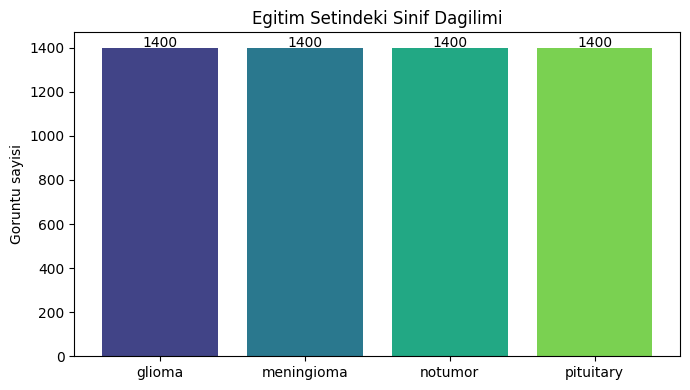

Toplam: 5600


In [11]:
plt.figure(figsize=(7,4))
bars = plt.bar(CLASS_NAMES, counts, color=sns.color_palette("viridis", NUM_CLASSES))
plt.title("Egitim Setindeki Sinif Dagilimi"); plt.ylabel("Goruntu sayisi")
for b in bars: plt.text(b.get_x()+b.get_width()/2, b.get_height()+5, int(b.get_height()), ha='center')
plt.tight_layout(); plt.show()
print("Toplam:", counts.sum())


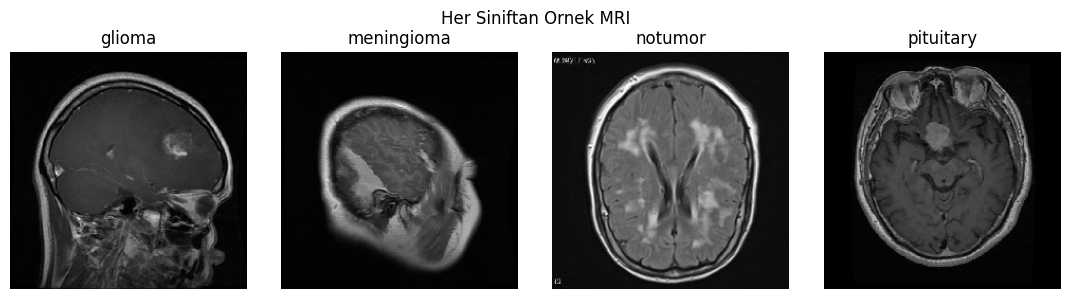

In [12]:
plt.figure(figsize=(11,3))
for i, c in enumerate(CLASS_NAMES):
    f = os.path.join(TRAIN_DIR, c); p = os.path.join(f, os.listdir(f)[0])
    img = keras.utils.load_img(p, target_size=IMG_SIZE)
    plt.subplot(1, NUM_CLASSES, i+1); plt.imshow(img); plt.title(c); plt.axis('off')
plt.suptitle("Her Siniftan Ornek MRI"); plt.tight_layout(); plt.show()


## 4. Model Kurma ve Iki Fazli Egitim Fonksiyonlari

`build_model` taban agi ve modeli birlikte dondurur .
`train_two_phase` once donuk egitim, sonra ince ayar yapar.


In [13]:
def build_model(backbone_name):
    """Onceden egitilmis taban ag + siniflandirici dondurur. (model, base) verir."""
    if backbone_name == "EfficientNetB0":
        from tensorflow.keras.applications import EfficientNetB0 as Net
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif backbone_name == "MobileNetV2":
        from tensorflow.keras.applications import MobileNetV2 as Net
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    elif backbone_name == "ResNet50":
        from tensorflow.keras.applications import ResNet50 as Net
        from tensorflow.keras.applications.resnet50 import preprocess_input
    else:
        raise ValueError(backbone_name)

    base = Net(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,))
    base.trainable = False                         # Faz 1: taban donuk

    inputs = keras.Input(shape=IMG_SIZE+(3,))
    x = data_augmentation(inputs)                  # veri artirma
    x = preprocess_input(x)                        # mimariye ozel normalizasyon
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)         # ozellik vektoru
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name=backbone_name)
    return model, base

def get_cb(patience=3):
    return [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience,
                                          restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                              patience=2, min_lr=1e-7)]

def train_two_phase(name, e1=12, e2=10, unfreeze_from=0.4):
    """Faz1: donuk egitim. Faz2: ust katmanlari cozup ince ayar."""
    model, base = build_model(name)

    # ---- FAZ 1: donuk taban, normal LR ----
    print(f"\n[{name}] FAZ 1 - donuk egitim")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=e1,
                   class_weight=CLASS_WEIGHT, callbacks=get_cb(3), verbose=1)

    # ---- FAZ 2: ince ayar ----
    print(f"[{name}] FAZ 2 - ince ayar")
    base.trainable = True
    cut = int(len(base.layers) * unfreeze_from)          # alt katmanlar donuk kalir
    for i, l in enumerate(base.layers):
        if i < cut: l.trainable = False
        if isinstance(l, layers.BatchNormalization):     # BN her zaman donuk (kararlilik)
            l.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5), # cok dusuk LR
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=e2,
                   class_weight=CLASS_WEIGHT, callbacks=get_cb(4), verbose=1)

    hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
    hist["phase1_end"] = len(h1.history["loss"])
    return model, hist


## 5. Modelleri Egit ve Karsilastir



In [14]:
MODELS_TO_TRAIN = ["EfficientNetB0", "MobileNetV2", "ResNet50"]


models, histories = {}, {}
for name in MODELS_TO_TRAIN:
    m, h = train_two_phase(name, e1=12, e2=10, unfreeze_from=0.4)
    models[name], histories[name] = m, h


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

[EfficientNetB0] FAZ 1 - donuk egitim
Epoch 1/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.6603 - loss: 0.8358 - val_accuracy: 0.7634 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 2/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.7797 - loss: 0.5805 - val_accuracy: 0.7509 - val_loss: 0.5886 - learning_rate: 0.0010
Epoch 3/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.8094 - loss: 0.5167 - val_accuracy: 0.7866 - val_loss: 0.5200 - learning_rate: 0.0010
Epoch 4/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.8257 - loss: 0.4849 - val_accuracy: 0.7973 - val_loss: 0.5067 - learning_rate: 0.0010
Epoch 5/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.8353 - loss: 0.4510 - val_accuracy: 0.8071 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 6/12
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.8286 - loss: 0.4433 - val_accuracy: 0.8071 - val_loss: 0.4763 - learnin

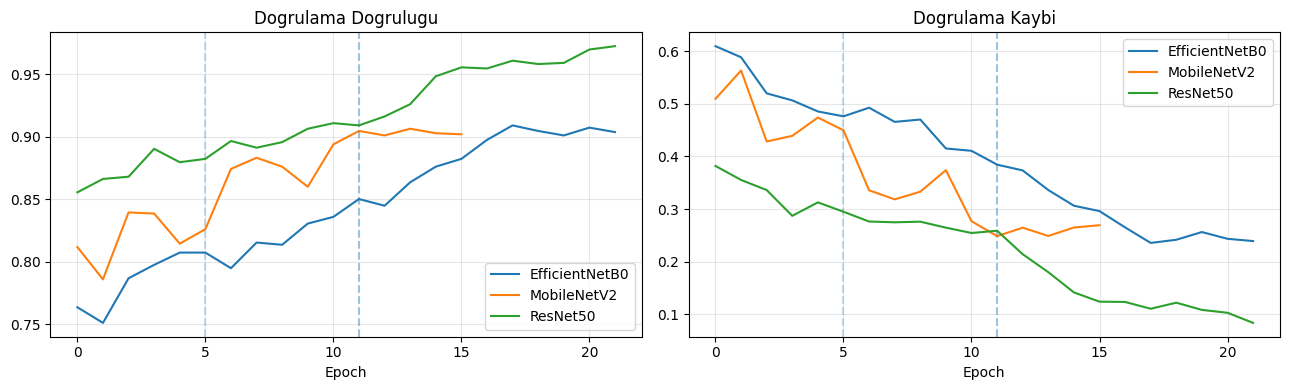

In [15]:
# --- Egitim egrileri ---
fig, ax = plt.subplots(1, 2, figsize=(13,4))
for name, h in histories.items():
    ax[0].plot(h['val_accuracy'], label=name)
    ax[1].plot(h['val_loss'], label=name)
    ax[0].axvline(h['phase1_end']-1, ls='--', alpha=.25)
    ax[1].axvline(h['phase1_end']-1, ls='--', alpha=.25)
ax[0].set_title("Dogrulama Dogrulugu"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_title("Dogrulama Kaybi"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 6. Test Setinde Degerlendirme

In [16]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
results, preds = {}, {}
for name, m in models.items():
    prob = m.predict(test_ds, verbose=0)
    acc = (prob.argmax(1) == y_true).mean()
    results[name], preds[name] = acc, prob
    print(f"{name:16s} Test Dogrulugu: {acc*100:.2f}%")
best_name = max(results, key=results.get)
print(f"\n>>> En iyi model: {best_name} ({results[best_name]*100:.2f}%)")


EfficientNetB0   Test Dogrulugu: 84.88%
MobileNetV2      Test Dogrulugu: 85.12%
ResNet50         Test Dogrulugu: 92.62%

>>> En iyi model: ResNet50 (92.62%)


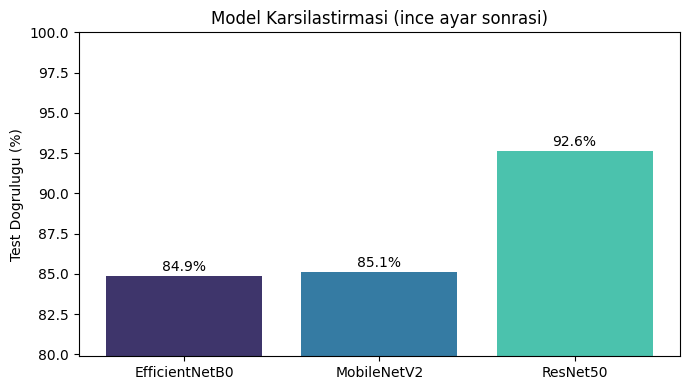

In [17]:
plt.figure(figsize=(7,4))
names=list(results); accs=[results[n]*100 for n in names]
bars=plt.bar(names, accs, color=sns.color_palette("mako", len(names)))
plt.ylim(max(0,min(accs)-5),100); plt.ylabel("Test Dogrulugu (%)")
plt.title("Model Karsilastirmasi (ince ayar sonrasi)")
for b,a in zip(bars,accs): plt.text(b.get_x()+b.get_width()/2, a+0.3, f"{a:.1f}%", ha='center')
plt.tight_layout(); plt.show()


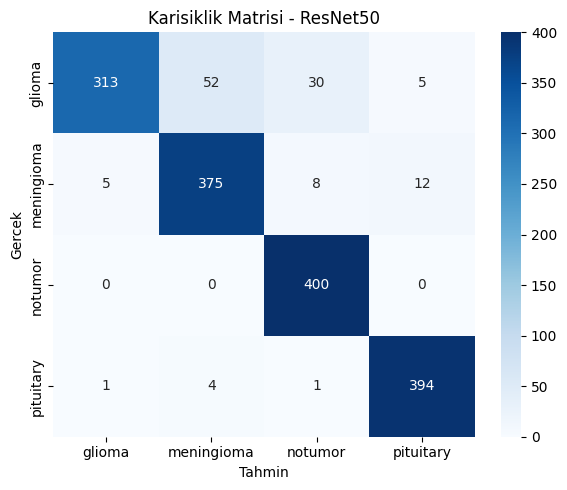

              precision    recall  f1-score   support

      glioma      0.981     0.782     0.871       400
  meningioma      0.870     0.938     0.903       400
     notumor      0.911     1.000     0.954       400
   pituitary      0.959     0.985     0.972       400

    accuracy                          0.926      1600
   macro avg      0.930     0.926     0.925      1600
weighted avg      0.930     0.926     0.925      1600



In [18]:
# --- En iyi modelin karisiklik matrisi + siniflandirma raporu ---
yb = preds[best_name].argmax(1)
cm = confusion_matrix(y_true, yb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Karisiklik Matrisi - {best_name}"); plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout(); plt.show()
print(classification_report(y_true, yb, target_names=CLASS_NAMES, digits=3))


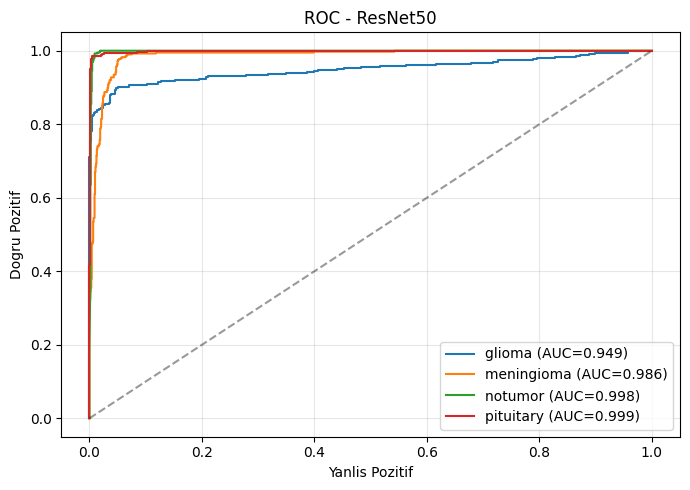

In [19]:
# --- ROC egrileri (bire-karsi-hepsi) ---
ybin = label_binarize(y_true, classes=range(NUM_CLASSES)); pb = preds[best_name]
plt.figure(figsize=(7,5))
for i,c in enumerate(CLASS_NAMES):
    fpr,tpr,_ = roc_curve(ybin[:,i], pb[:,i])
    plt.plot(fpr,tpr,label=f"{c} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],'k--',alpha=.4); plt.legend(); plt.grid(alpha=.3)
plt.xlabel("Yanlis Pozitif"); plt.ylabel("Dogru Pozitif"); plt.title(f"ROC - {best_name}")
plt.tight_layout(); plt.show()


## 7. Asama 1 — Tumor TESPITI (Ikili)
4-sinifli tahminler `notumor` vs `tumor` olarak birlestirilir.


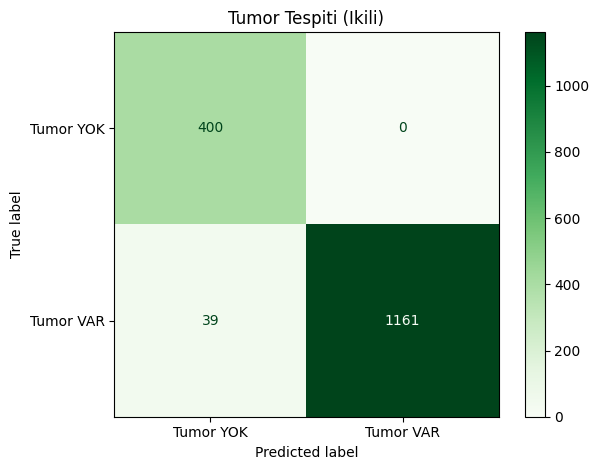

Accuracy   : 97.56%
Sensitivity: 96.75%  <- tumoru kacirmama orani
Specificity: 100.00%
              precision    recall  f1-score   support

   Tumor YOK      0.911     1.000     0.954       400
   Tumor VAR      1.000     0.968     0.983      1200

    accuracy                          0.976      1600
   macro avg      0.956     0.984     0.968      1600
weighted avg      0.978     0.976     0.976      1600



In [20]:
ni = CLASS_NAMES.index('notumor')
tb = lambda a: (a != ni).astype(int)
yt, yp = tb(y_true), tb(yb)
cm2 = confusion_matrix(yt, yp)
ConfusionMatrixDisplay(cm2, display_labels=['Tumor YOK','Tumor VAR']).plot(cmap='Greens', values_format='d')
plt.title("Tumor Tespiti (Ikili)"); plt.tight_layout(); plt.show()
tn,fp,fn,tp = cm2.ravel()
print(f"Accuracy   : {(tp+tn)/cm2.sum()*100:.2f}%")
print(f"Sensitivity: {tp/(tp+fn)*100:.2f}%  <- tumoru kacirmama orani")
print(f"Specificity: {tn/(tn+fp)*100:.2f}%")
print(classification_report(yt, yp, target_names=['Tumor YOK','Tumor VAR'], digits=3))


## 8. Ornek Tahminler + Grad-CAM



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_412']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


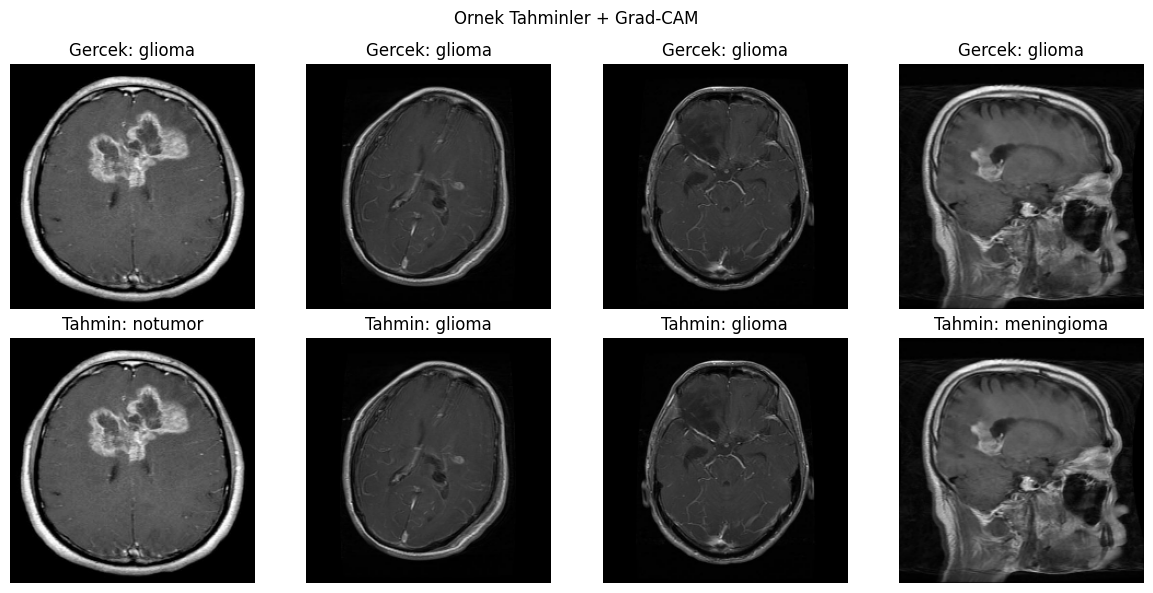

In [21]:
import cv2
def gradcam(model, img):
    base = max([l for l in model.layers if isinstance(l, keras.Model)], key=lambda m: len(m.layers))
    conv = [l.name for l in base.layers if 'conv' in l.name.lower()][-1]
    gm = keras.models.Model(base.inputs, [base.get_layer(conv).output, base.output])
    x = img[None].astype('float32')
    with tf.GradientTape() as t:
        co, _ = gm(x); pr = model(x, training=False)
        cls = tf.argmax(pr[0]); loss = pr[:, cls]
    g = t.gradient(loss, co); pooled = tf.reduce_mean(g, axis=(0,1,2))
    h = tf.reduce_sum(co[0]*pooled, -1); h = tf.maximum(h,0)/(tf.reduce_max(h)+1e-8)
    return h.numpy(), int(cls)

imgs, lbls = next(iter(test_ds)); bm = models[best_name]
plt.figure(figsize=(12,6))
for i in range(4):
    im = imgs[i].numpy().astype('uint8')
    try:
        h, cls = gradcam(bm, im.astype('float32'))
        h = np.uint8(255*cv2.resize(h, IMG_SIZE))
        ov = cv2.addWeighted(im, 0.6, cv2.applyColorMap(h, cv2.COLORMAP_JET), 0.4, 0)
    except Exception:
        ov = im; cls = int(bm.predict(im[None], verbose=0).argmax())
    plt.subplot(2,4,i+1); plt.imshow(im); plt.axis('off'); plt.title(f"Gercek: {CLASS_NAMES[int(lbls[i])]}")
    plt.subplot(2,4,i+5); plt.imshow(ov); plt.axis('off'); plt.title(f"Tahmin: {CLASS_NAMES[cls]}")
plt.suptitle("Ornek Tahminler + Grad-CAM"); plt.tight_layout(); plt.show()


## 9. En Iyi Modeli Kaydet

In [22]:
bm.save(f"beyin_tumoru_{best_name}.keras")
print("Kaydedildi:", f"beyin_tumoru_{best_name}.keras")
try:
    from google.colab import files; files.download(f"beyin_tumoru_{best_name}.keras")
except Exception: pass


Kaydedildi: beyin_tumoru_ResNet50.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>